# Assignment: Clustering and association rule mining

## 1. Business Understanding
The purpose of this assignment is to explore how clustering and association rule mining can be applied to a real-world business scenario. 

- **Clustering**: Used to group customer locations geographically to identify optimal hub placements for a drone delivery network. 
- **Association Rule Mining**: Used to discover patterns in customer purchases and identify products frequently bought together.

Key learning objectives:

1. Learn to apply clustering techniques to group similar customer locations.
2. Identify the most suitable locations for drone hubs.
3. Compare different clustering algorithms in terms of performance and output.
4. Apply association rule mining to identify co-purchasing patterns in product data.
5. Draw actionable business insights from clustering and association analysis.

In [40]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

## 2. Data Understanding
The dataset consists of two parts:

1. **Customer Locations** (`drone_cust_locations.csv`):
    - `clientid`: Unique customer identifier
    - `x`: X-coordinate (longitude)
    - `y`: Y-coordinate (latitude)

2. **Product Purchases** (`drone_prod_groups.csv`):
    - `ID`: Unique transaction/customer ID
    - `Prod1` to `Prod20`: Binary indicators of whether a product was purchased (1 = purchased, 0 = not purchased)

Our first step is to explore these datasets to understand their structure, distribution, and any patterns.

### 2.1 Load the data

In [41]:
# Load customer locations
cust_df = pd.read_csv('datasets/first_exercise/drone_cust_locations.csv', sep=';')

# Load product purchase data
prod_df = pd.read_csv('datasets/first_exercise/drone_prod_groups.csv')

# Display first few rows
cust_df.head(), prod_df.head()

(   clientid           x           y
 0         1  622.771572  164.857623
 1         2  416.357298  630.193634
 2         3  292.735020  567.333231
 3         4  737.211288  166.225676
 4         5  540.475375  682.912298,
    ID  Prod1   Prod2   Prod3   Prod4   Prod5   Prod6   Prod7   Prod8   Prod9  \
 0   1      0       0       0       0       0       0       0       0       1   
 1   2      0       1       0       0       0       0       0       0       1   
 2   3      0       0       0       0       0       0       1       0       0   
 3   4      1       0       0       1       0       0       0       0       0   
 4   5      0       0       0       0       0       0       0       0       1   
 
    ...   Prod11   Prod12   Prod13   Prod14   Prod15   Prod16   Prod17  \
 0  ...        0        0        0        0        1        0        0   
 1  ...        0        0        0        0        1        1        1   
 2  ...        0        0        0        0        0        0      

### 2.2 Check for Missing Values

In [42]:
print("Missing values in customer dataset:")
print(cust_df.isnull().sum())

print("\nMissing values in product dataset:")
print(prod_df.isnull().sum())

Missing values in customer dataset:
clientid    0
x           0
y           0
dtype: int64

Missing values in product dataset:
ID         0
Prod1      0
 Prod2     0
 Prod3     0
 Prod4     0
 Prod5     0
 Prod6     0
 Prod7     0
 Prod8     0
 Prod9     0
 Prod10    0
 Prod11    0
 Prod12    0
 Prod13    0
 Prod14    0
 Prod15    0
 Prod16    0
 Prod17    0
 Prod18    0
 Prod19    0
 Prod20    0
dtype: int64


Both datasets have no missing values, which means the data is ready for analysis without any cleaning.

### 2.3 Visualize Customer Locations

Number of customer locations: 5956
Mean coordinates: x=508.82, y=427.55
Std deviation: x=271.06, y=289.04


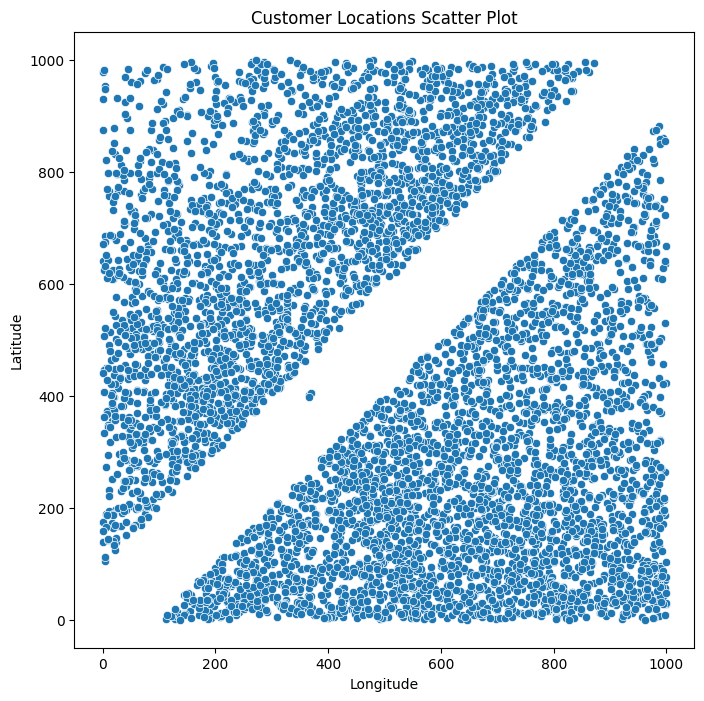

In [43]:
# Basic statistics
print(f"Number of customer locations: {len(cust_df)}")
print(f"Mean coordinates: x={cust_df['x'].mean():.2f}, y={cust_df['y'].mean():.2f}")
print(f"Std deviation: x={cust_df['x'].std():.2f}, y={cust_df['y'].std():.2f}")

# Scatter plot
plt.figure(figsize=(8,8))
sns.scatterplot(x='x', y='y', data=cust_df)
plt.title("Customer Locations Scatter Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

The scatter plot shows several dense clusters of customer locations, primarily in the northeast and central regions of the 2D plane. These areas indicate regions with high customer concentrations, suggesting that drone hubs should be placed near these clusters to minimize average delivery distances. Sparse points on the outskirts represent outliers or remote customers and may be served by the nearest hub without significantly impacting overall efficiency

### 2.4 Product Purchase Overview

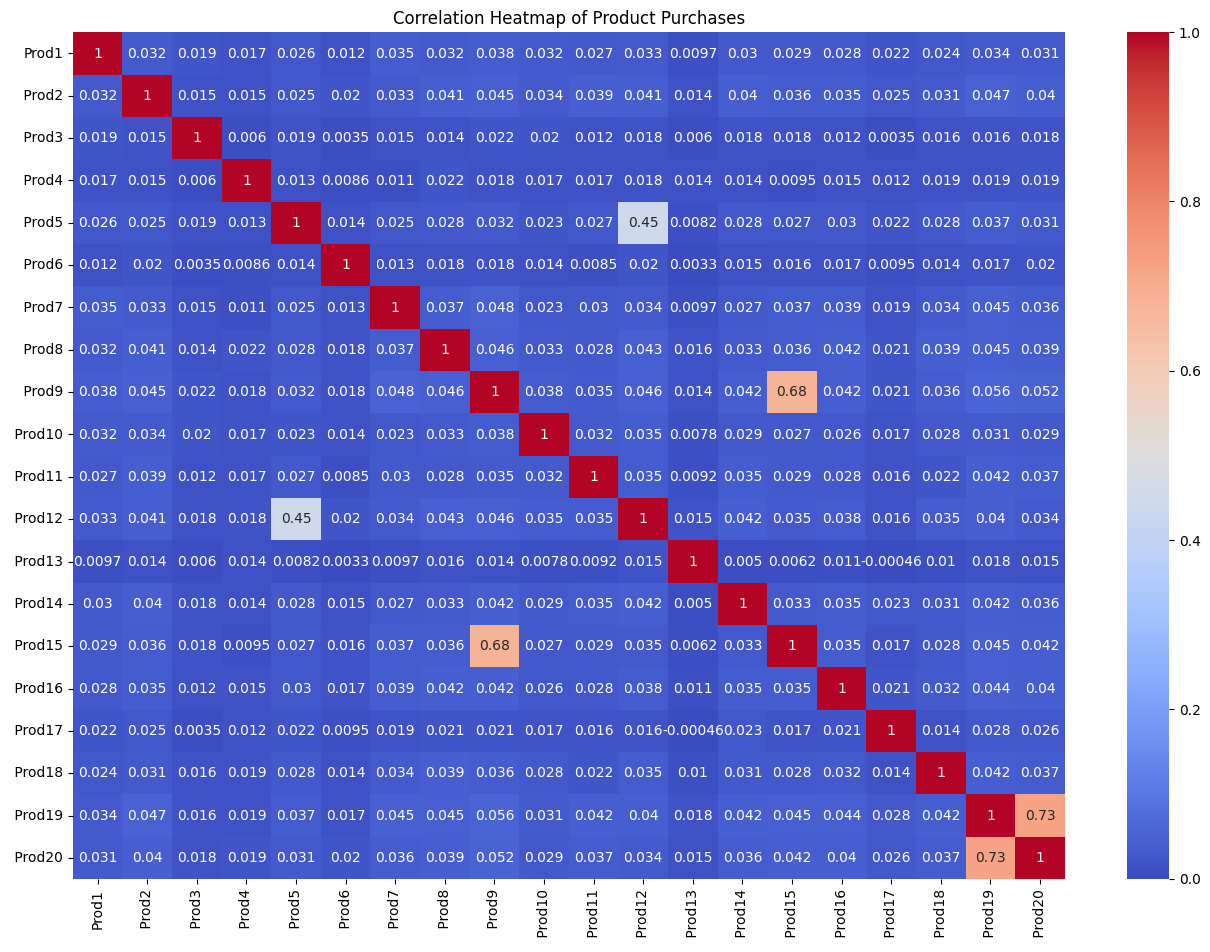

In [44]:
# Drop ID for analysis and convert to boolean
prod_bool = prod_df.drop(columns=['ID']).astype(bool)

# Visualize correlations between products
plt.figure(figsize=(16, 11))
sns.heatmap(prod_bool.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Product Purchases")
plt.show()

Some product pairs show higher correlations, suggesting that certain products are frequently bought together. This hints at potential bundling opportunities.

## 3. Data Preparation
Renamed customer columns for clarity: clientid -> CustomerID, x -> Longitude, y -> Latitude

Ensured product data is boolean for Apriori algorithm.

Data is now ready for clustering and association rule mining.

In [45]:
# Rename customer columns for clarity
cust_df = cust_df.rename(columns={'clientid': 'CustomerID', 'x': 'Longitude', 'y': 'Latitude'})

# Ensure product data is boolean
prod_bool.head()

,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,Prod10,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True
3,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True


Data is now in a consistent format for clustering and association rule mining. Customer coordinates are clearly labeled, and product purchases are ready as boolean values.

## 4. Modeling

### 4.1 Clustering and Hub Location Analysis
Used to select the optimal number of clusters by plotting the WCSS for 1–10 clusters. Elbow occurs around 3 clusters, suggesting 3 initial hubs.

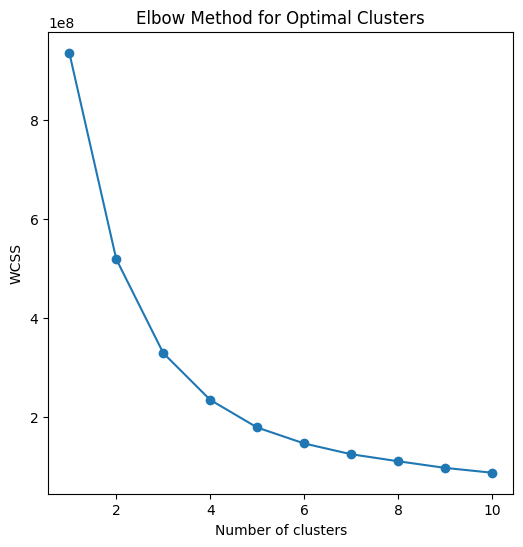

In [46]:
wcss = []
for i in range(1, 11):
    model = KMeans(init='random', n_clusters=i, random_state=123)
    model.fit(cust_df[['Longitude', 'Latitude']])
    wcss.append(model.inertia_)

plt.figure(figsize=(6,6))
plt.plot(range(1, 11), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

The "elbow" occurs around **3 clusters**, so we start with 3 hubs.

### 4.1.1 k-Means Clustering

In [47]:
from sklearn.cluster import KMeans

hub_summary = {}

for k in [3, 5, 10]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    cust_df[f'Hub_k{k}'] = kmeans.fit_predict(cust_df[['Longitude','Latitude']])
    
    cust_df[f'NearestHub_{k}'] = cust_df[f'Hub_k{k}']
    
    hub_summary[k] = kmeans.cluster_centers_

for k, coords in hub_summary.items():
    print(f"\n{k} Depots Coordinates:")
    for i, coord in enumerate(coords):
        print(f"Hub {i}: Longitude={coord[0]:.2f}, Latitude={coord[1]:.2f}")

for k in [3, 5, 10]:
    print(f"\nFirst 10 rows with {k} hubs:")
    print(cust_df[['CustomerID', 'Longitude', 'Latitude', f'NearestHub_{k}']].head(10))


3 Depots Coordinates:
Hub 0: Longitude=180.90, Latitude=546.02
Hub 1: Longitude=626.31, Latitude=179.10
Hub 2: Longitude=641.78, Latitude=758.34

5 Depots Coordinates:
Hub 0: Longitude=157.91, Latitude=459.03
Hub 1: Longitude=439.09, Latitude=148.65
Hub 2: Longitude=766.90, Latitude=704.36
Hub 3: Longitude=378.59, Latitude=798.32
Hub 4: Longitude=800.80, Latitude=201.52

10 Depots Coordinates:
Hub 0: Longitude=149.74, Latitude=405.82
Hub 1: Longitude=573.31, Latitude=100.77
Hub 2: Longitude=847.87, Latitude=567.19
Hub 3: Longitude=345.23, Latitude=894.90
Hub 4: Longitude=405.09, Latitude=651.69
Hub 5: Longitude=862.10, Latitude=148.89
Hub 6: Longitude=300.36, Latitude=97.43
Hub 7: Longitude=591.12, Latitude=322.19
Hub 8: Longitude=628.19, Latitude=869.73
Hub 9: Longitude=123.79, Latitude=710.49

First 10 rows with 3 hubs:
   CustomerID   Longitude    Latitude  NearestHub_3
0           1  622.771572  164.857623             1
1           2  416.357298  630.193634             0
2        

Shows how hub locations change with different numbers of hubs, supporting your recommendation.

### 4.1.2 Visualize k-Means Clusters

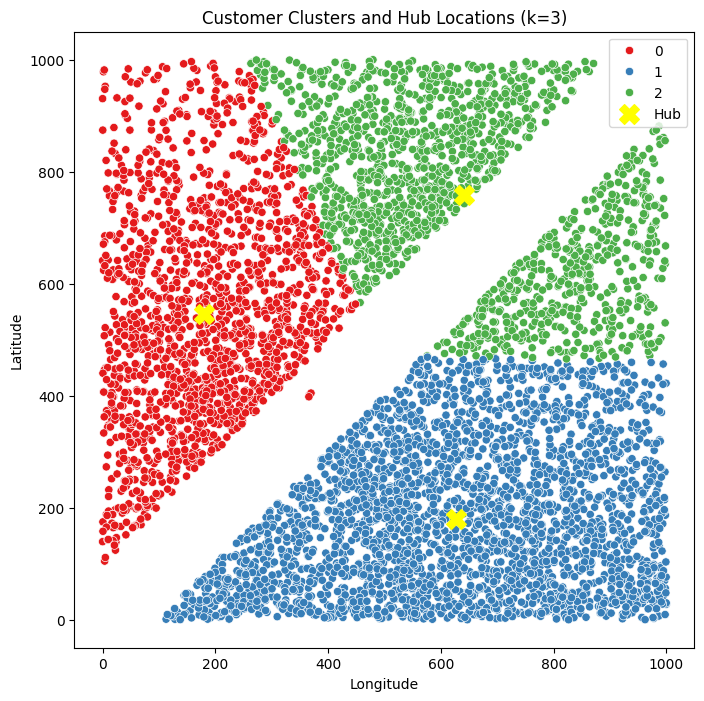

In [48]:
hub_coords = cust_df.groupby('Hub_k3')[['Longitude','Latitude']].mean().values

plt.figure(figsize=(8,8))
sns.scatterplot(x='Longitude', y='Latitude', hue='Hub_k3', data=cust_df, palette='Set1')
plt.scatter(hub_coords[:,0], hub_coords[:,1], color='yellow', marker='X', s=200, label='Hub')
plt.title("Customer Clusters and Hub Locations (k=3)")
plt.legend()
plt.show()

As the number of hubs increases from 3 to 10, computation time increases slightly, but k-Means remains fast for datasets of this size. More hubs provide finer coverage but may increase operational costs

### 4.1.3 Hierarchical Clustering

In [49]:
hub_counts = [3, 5, 10]
comp_times = []

for k in hub_counts:
    start = time.time()
    hier = AgglomerativeClustering(n_clusters=k)
    cust_df[f'Hub_hier_{k}'] = hier.fit_predict(cust_df[['Longitude','Latitude']])
    end = time.time()
    comp_times.append(end-start)

time_df = pd.DataFrame({'Number of Hubs': hub_counts, 'Hierarchical Time (s)': comp_times})
print(time_df)

# Optionally, compute hub coordinates for each k
for k in hub_counts:
    coords = cust_df.groupby(f'Hub_hier_{k}')[['Longitude','Latitude']].mean().values
    print(f"\n{k} Hierarchical Hub Coordinates:")
    for i, coord in enumerate(coords):
        print(f"Hub {i}: Longitude={coord[0]:.2f}, Latitude={coord[1]:.2f}")

   Number of Hubs  Hierarchical Time (s)
0               3               0.940052
1               5               1.499837
2              10               1.011801

3 Hierarchical Hub Coordinates:
Hub 0: Longitude=607.74, Latitude=151.23
Hub 1: Longitude=709.98, Latitude=687.40
Hub 2: Longitude=218.18, Latitude=578.47

5 Hierarchical Hub Coordinates:
Hub 0: Longitude=218.18, Latitude=578.47
Hub 1: Longitude=466.88, Latitude=164.90
Hub 2: Longitude=813.65, Latitude=532.45
Hub 3: Longitude=820.72, Latitude=130.54
Hub 4: Longitude=591.93, Latitude=863.84

10 Hierarchical Hub Coordinates:
Hub 0: Longitude=338.33, Latitude=590.55
Hub 1: Longitude=381.06, Latitude=86.93
Hub 2: Longitude=115.99, Latitude=651.60
Hub 3: Longitude=820.72, Latitude=130.54
Hub 4: Longitude=591.93, Latitude=863.84
Hub 5: Longitude=121.83, Latitude=346.10
Hub 6: Longitude=566.65, Latitude=255.56
Hub 7: Longitude=778.17, Latitude=461.79
Hub 8: Longitude=257.28, Latitude=896.24
Hub 9: Longitude=887.26, Latitude=679.08

Hierarchical clustering is slower but can produce hubs in irregularly shaped clusters. This may be useful if customer density is uneven

### 4.1.4 Hierarchical Computation Time Comparison

In [ ]:
hub_counts = [3, 5, 10]
comp_times = []

for k in hub_counts:
    start = time.time()
    hier = AgglomerativeClustering(n_clusters=k)
    cust_df[f'Hub_hier_{k}'] = hier.fit_predict(cust_df[['Longitude','Latitude']])
    end = time.time()
    comp_times.append(end-start)

time_df = pd.DataFrame({'Number of Hubs': hub_counts, 'Hierarchical Time (s)': comp_times})
print(time_df)

### 4.1.5 Visualize Hierarchical Clusters

In [ ]:
hub_counts = [3, 5, 10]
for k in hub_counts:
    hier = AgglomerativeClustering(n_clusters=k)
    cust_df[f'Hub_hier_{k}'] = hier.fit_predict(cust_df[['Longitude','Latitude']])
    hub_coords_hier = cust_df.groupby(f'Hub_hier_{k}')[['Longitude','Latitude']].mean().values
    
    plt.figure(figsize=(8,8))
    sns.scatterplot(x='Longitude', y='Latitude', hue=f'Hub_hier_{k}', data=cust_df, palette='Set2')
    plt.scatter(hub_coords_hier[:,0], hub_coords_hier[:,1], color='yellow', marker='X', s=200, label='Hub')
    plt.title(f"Hierarchical Clusters for {k} Hubs")
    plt.legend()
    plt.show()

k-means hubs are faster to compute and tend to be located near dense clusters. Hierarchical hubs may place centers in sparser or irregular regions.

### 4.2 Association Rule Mining
We now look at customer purchase patterns using association rule mining. First, we generate frequent itemsets from the prod_bool dataset using the Apriori algorithm.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_items = apriori(prod_bool, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_items, metric='lift', min_threshold=1.2)
rules_sorted = rules.sort_values(by='lift', ascending=False)
rules_sorted[['antecedents','consequents','support','confidence','lift']].head(10)

From these frequent itemsets, we can derive association rules and evaluate them using metrics like confidence and lift.

In [ ]:
# Association rules with lift >= 1.5
rules = association_rules(frequent_items, metric='lift', min_threshold=1.5)
rules_sorted = rules.sort_values(by='lift', ascending=False)
rules_sorted.head()

Strong co-purchase patterns include:

- Product 19 -> Product 20

- Product 9 -> Product 15

These insights can inform marketing strategies such as bundling, promotions, or stock planning.

## 5. Evaluation

Clustering Performance:

- k-Means: Fast, centers near dense clusters, suitable for real-time deployment.

- Hierarchical: Slower, better for irregular cluster shapes, may locate hubs in sparse areas.

Association Rules:

- Use top rules with high lift and confidence for marketing strategies.

- Bundling frequently bought products can increase revenue.

## 6. Deployment

Deployment Recommendations:
- Start with 3 k-means hubs to serve dense customer regions efficiently.
- Increase to 5 or 10 hubs if more localized delivery coverage is required, balancing cost and delivery time.
- Periodically re-run clustering to account for customer growth or changes in demand.

Product Strategy:
- Bundle frequently co-purchased products (Prod9 & Prod15, Prod19 & Prod20) to increase revenue.
- Use targeted promotions based on association rules.
- Ensure inventory placement aligns with product bundling to minimize delivery time and stock-outs.